<a href="https://colab.research.google.com/github/Shreyapowar9961/Deep_Learning_sem6/blob/main/Lab7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Experiment No. 07

Name : Shreya Nandkumar Powar

Class : TYDS-65

PRN : 2324001231

Github Repo :

VGG16 with Different Dropout Rates

In [ ]:
# Import Libraries
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense
from tensorflow.keras.layers import Dropout
import matplotlib.pyplot as plt

# Load Dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Normalize Dataset
x_train = x_train / 255.0
x_test = x_test / 255.0

# Reshape Dataset
x_train = x_train.reshape(-1,28,28,1)
x_test = x_test.reshape(-1,28,28,1)

# Function to Create Model
def create_model(drop_rate):

    model = Sequential()

    model.add(Conv2D(32,(3,3),
                     activation='relu',
                     input_shape=(28,28,1)))

    model.add(MaxPooling2D((2,2)))

    model.add(Conv2D(64,(3,3),
                     activation='relu'))

    model.add(MaxPooling2D((2,2)))

    model.add(Flatten())

    model.add(Dense(128,
                    activation='relu'))

    model.add(Dropout(drop_rate))

    model.add(Dense(10,
                    activation='softmax'))

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

# Dropout Rates
dropouts = [0.2, 0.5, 0.8]

histories = []

# Train Models
for rate in dropouts:

    print(f"\nTraining Model with Dropout = {rate}")

    model = create_model(rate)

    history = model.fit(
        x_train,
        y_train,
        epochs=5,
        validation_split=0.2
    )

    histories.append((rate, history))

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

Training Model with Dropout = 0.2


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 54s 35ms/step - accuracy: 0.9472 - loss: 0.1712 - val_accuracy: 0.9804 - val_loss: 0.0627
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 77s 32ms/step - accuracy: 0.9833 - loss: 0.0563 - val_accuracy: 0.9824 - val_loss: 0.0596
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 84s 33ms/step - accuracy: 0.9880 - loss: 0.0390 - val_accuracy: 0.9875 - val_loss: 0.0408
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 83s 34ms/step - accuracy: 0.9900 - loss: 0.0309 - val_accuracy: 0.9897 - val_loss: 0.0355
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 81s 33ms/step - accuracy: 0.9918 - loss: 0.0248 - val_accuracy: 0.9902 - val_loss: 0.0367

Training Model with Dropout = 0.5
Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 50s 33ms/step - accuracy: 0.9316 - loss: 0.2240 - val_accuracy: 0.9824 - val_loss: 0.0588
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 82s 33ms/step - accuracy: 0.9748 - loss: 0.0841 - val_accuracy: 0.9860 - val_loss: 0.0476
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 81s 32m

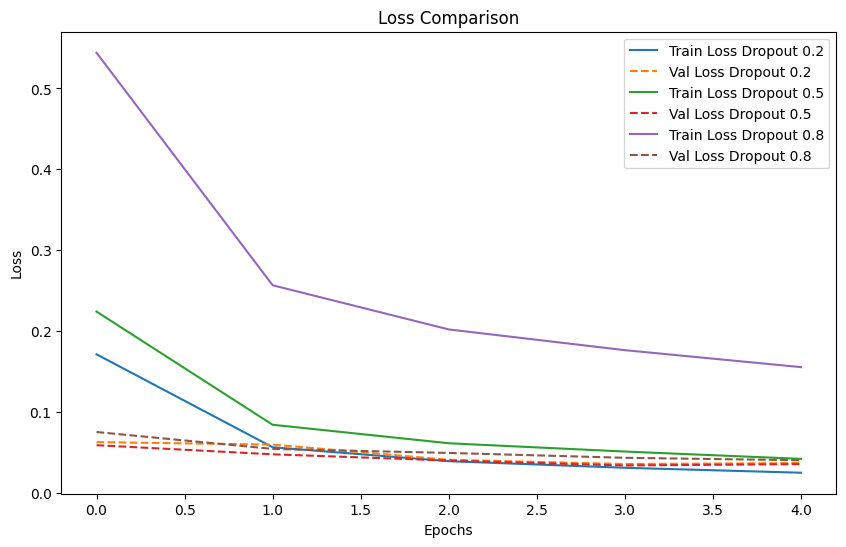

In [ ]:
plt.figure(figsize=(10,6))

for rate, history in histories:

    plt.plot(
        history.history['loss'],
        label=f'Train Loss Dropout {rate}'
    )

    plt.plot(
        history.history['val_loss'],
        linestyle='dashed',
        label=f'Val Loss Dropout {rate}'
    )

plt.title("Loss Comparison")

plt.xlabel("Epochs")
plt.ylabel("Loss")

plt.legend()

plt.show()

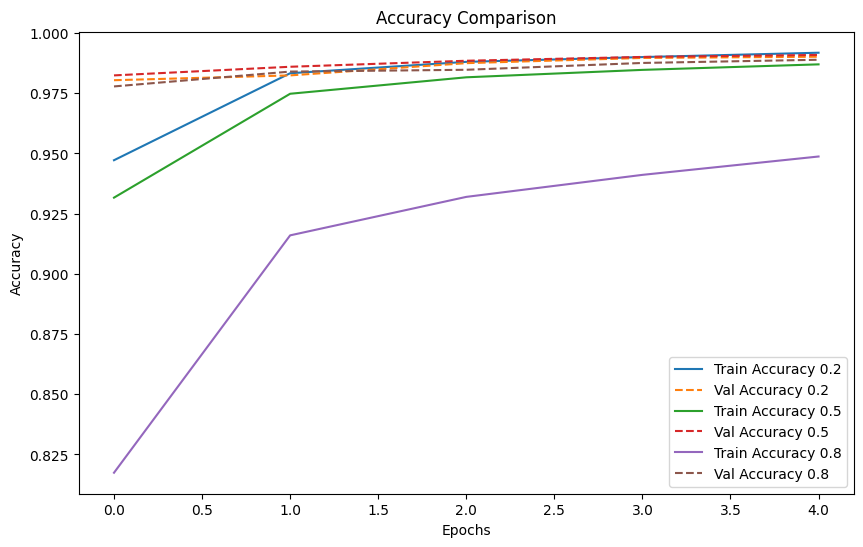

In [ ]:
plt.figure(figsize=(10,6))

for rate, history in histories:

    plt.plot(
        history.history['accuracy'],
        label=f'Train Accuracy {rate}'
    )

    plt.plot(
        history.history['val_accuracy'],
        linestyle='dashed',
        label=f'Val Accuracy {rate}'
    )

plt.title("Accuracy Comparison")

plt.xlabel("Epochs")
plt.ylabel("Accuracy")

plt.legend()

plt.show()

VGG16 with Batch Normalization and Dropout

In [ ]:
# Import BatchNormalization
from tensorflow.keras.layers import BatchNormalization

# Function to Create Model
def create_bn_model(drop_rate):

    model = Sequential()

    model.add(Conv2D(32,(3,3),
                     activation='relu',
                     input_shape=(28,28,1)))

    model.add(BatchNormalization())

    model.add(MaxPooling2D((2,2)))

    model.add(Conv2D(64,(3,3),
                     activation='relu'))

    model.add(BatchNormalization())

    model.add(MaxPooling2D((2,2)))

    model.add(Flatten())

    model.add(Dense(128,
                    activation='relu'))

    model.add(BatchNormalization())

    model.add(Dropout(drop_rate))

    model.add(Dense(10,
                    activation='softmax'))

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

# Train Models
bn_histories = []

for rate in dropouts:

    print(f"\nTraining BatchNorm Model with Dropout = {rate}")

    model = create_bn_model(rate)

    history = model.fit(
        x_train,
        y_train,
        epochs=5,
        validation_split=0.2
    )

    bn_histories.append((rate, history))


Training BatchNorm Model with Dropout = 0.2
Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 75s 48ms/step - accuracy: 0.9642 - loss: 0.1186 - val_accuracy: 0.9822 - val_loss: 0.0596
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 69s 46ms/step - accuracy: 0.9845 - loss: 0.0504 - val_accuracy: 0.9826 - val_loss: 0.0544
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 81s 46ms/step - accuracy: 0.9883 - loss: 0.0382 - val_accuracy: 0.9873 - val_loss: 0.0402
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 69s 46ms/step - accuracy: 0.9895 - loss: 0.0331 - val_accuracy: 0.9873 - val_loss: 0.0427
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 69s 46ms/step - accuracy: 0.9930 - loss: 0.0227 - val_accuracy: 0.9883 - val_loss: 0.0388

Training BatchNorm Model with Dropout = 0.5
Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 71s 46ms/step - accuracy: 0.9516 - loss: 0.1596 - val_accuracy: 0.9846 - val_loss: 0.0507
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 83s 47ms/step - accuracy: 0.9789 - loss: 0.0677 - val_accuracy: 0.9857 - val_loss: 

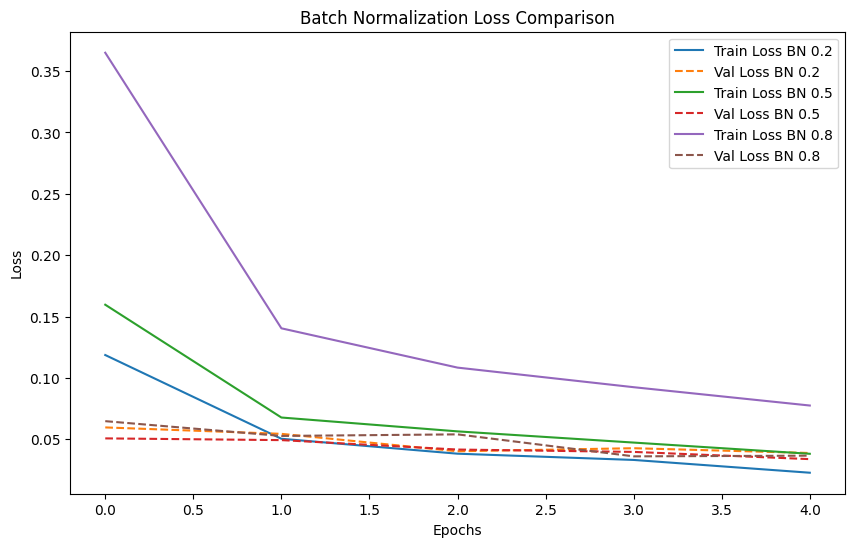

In [ ]:
plt.figure(figsize=(10,6))

for rate, history in bn_histories:

    plt.plot(
        history.history['loss'],
        label=f'Train Loss BN {rate}'
    )

    plt.plot(
        history.history['val_loss'],
        linestyle='dashed',
        label=f'Val Loss BN {rate}'
    )

plt.title("Batch Normalization Loss Comparison")

plt.xlabel("Epochs")
plt.ylabel("Loss")

plt.legend()

plt.show()

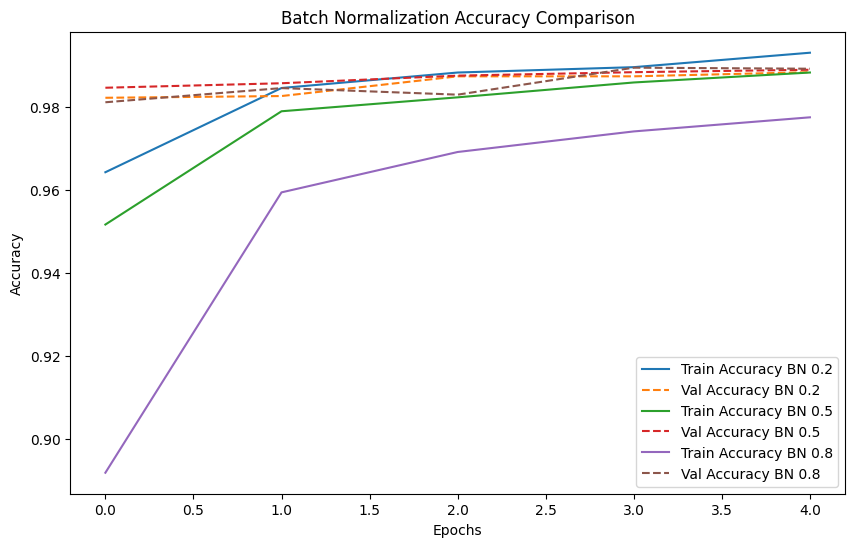

In [ ]:
plt.figure(figsize=(10,6))

for rate, history in bn_histories:

    plt.plot(
        history.history['accuracy'],
        label=f'Train Accuracy BN {rate}'
    )

    plt.plot(
        history.history['val_accuracy'],
        linestyle='dashed',
        label=f'Val Accuracy BN {rate}'
    )

plt.title("Batch Normalization Accuracy Comparison")

plt.xlabel("Epochs")
plt.ylabel("Accuracy")

plt.legend()

plt.show()